# Delirium Prediction Model - MIMIC

## Overview
- **Models**: Logistic Regression, Random Forest, XGBoost, Bidirectional LSTM
- **Evaluation**: 5-Fold Stratified Cross-Validation
- **Metrics**: ROC-AUC, AU-PRC, PPV, NPV, MCC, Specificity@90% Sensitivity

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import os
import sys
import random
import warnings
warnings.filterwarnings('ignore')

# Scipy & Stats
import scipy
import statsmodels.stats.api as sms

# Sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, recall_score, matthews_corrcoef
)

# XGBoost
from xgboost import XGBClassifier

# Visualization
import matplotlib.pyplot as plt

# # TensorFlow / Keras
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import backend as K
# from tensorflow.keras.models import Sequential, Model, load_model
# from tensorflow.keras.layers import (
#     Bidirectional, LSTM, Lambda, Dropout, Dense, 
#     Masking, Input, Reshape, Embedding, Concatenate
# )
# from tensorflow.keras import optimizers
# from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# print(f"TensorFlow version: {tf.__version__}")
# print(f"Pandas version: {pd.__version__}")

## 2. Configuration & Seed

In [2]:
# Random Seed for Reproducibility
SEED_VALUE = 36
np.random.seed(SEED_VALUE)
random.seed(SEED_VALUE)
# tf.random.set_seed(SEED_VALUE)

# GPU Configuration
# gpus = tf.config.experimental.list_physical_devices('GPU')
# if gpus:
#     try:
#         for gpu in gpus:
#             tf.config.experimental.set_memory_growth(gpu, True)
#         print(f"GPU available: {len(gpus)} device(s)")
#     except RuntimeError as e:
#         print(e)
# else:
#     print("No GPU available, using CPU")

In [3]:
# =============================================================================
# EXPERIMENT PARAMETERS - MODIFY HERE
# =============================================================================
MIN_TIME = 8       # Observation window (hours): 12, 24, 48
SKIP_TIME = 12      # Prediction horizon (hours): 12, 24, 48, 72, 96
HIGH_RECALL = False # True for higher recall model

# Model Hyperparameters
BATCH_SIZE = 128
PARAMS = {
    'lr': 0.000075,
    'hidden_units': 128,
    'dropout': 0.2,
    'epochs': 50
}

# Task identifier
TASK = f'{MIN_TIME}_{SKIP_TIME}'
print(f"Task: {TASK} (min_time={MIN_TIME}h, skip_time={SKIP_TIME}h, high_recall={HIGH_RECALL})")

Task: 8_12 (min_time=8h, skip_time=12h, high_recall=False)


## 3. Data Loading

In [13]:
# Data paths
DATA_DIR = "../Data/preprocessed"
POS_PATH = f"{DATA_DIR}/pos_mimic_imputed_24los.csv"
NEG_PATH = f"{DATA_DIR}/neg_mimic_imputed_24los.csv"

# Load positive and negative data separately
mimic_pos = pd.read_csv(POS_PATH)
mimic_neg = pd.read_csv(NEG_PATH)

print(f"Positive data shape: {mimic_pos.shape}")
print(f"Negative data shape: {mimic_neg.shape}")

# Combine into single dataframe
mimic_df = pd.concat([mimic_pos, mimic_neg], axis=0, ignore_index=True)

print(f"\nCombined data shape: {mimic_df.shape}")
print(f"Columns: {mimic_df.columns.tolist()}")

Positive data shape: (43576, 56)
Negative data shape: (814730, 56)

Combined data shape: (858306, 56)
Columns: ['patientunitstayid', 'itemoffset', 'HOURS', 'gender', 'age', 'admissionheight', 'admissionweight', 'Heart Rate', 'O2 Saturation', 'glucose', 'Temperature (C)', 'WBC x 1000', 'Diastolic blood pressure', 'Systolic blood pressure', 'Mean blood pressure', 'Respiratory rate', 'Hemoglobin', 'BUN', 'sodium', 'Potassium', 'Osmolality', 'FiO2', 'pH', 'PaCO2', 'PaO2', 'Ammonia', 'ICP', 'Cortisol', 'Sedative drugs', 'Opiate drugs', 'Benzodiazepine drugs', 'Delirium (disorder)', 'Hyperirritability (finding)', 'Feeling agitated (finding)', 'Feeling irritable (finding)', 'Fluctuation of level of consciousness (finding)', 'Disorientated in time (finding)', 'Aggressive behavior (finding)', 'Disorientated in place (finding)', 'Difficulty sleeping (finding)', 'Disorientation for person (finding)', 'Incoherent speech (finding)', 'Sleep disorder (disorder)', 'Memory impairment (finding)', 'Disor

In [14]:
# Check data sample
print("Sample data:")
mimic_df.head()

Sample data:


,patientunitstayid,itemoffset,HOURS,gender,age,admissionheight,admissionweight,Heart Rate,O2 Saturation,glucose,...,Asthenia (finding),Drowsy (finding),Difficulty communicating (finding),Finding of shouting (finding),LOS,RASS,CAM-ICU,labelrec,labelpt,CAM
0,0011090004171223260807004,1,1.733333,1,33.0,162.272403,47.6,90.0,100.0,226.0,...,0,1,0,0,53.28,-1.0,0.0,0.0,1.0,1.0
1,0011090004171223260807004,2,2.733333,1,33.0,162.272403,47.6,88.0,100.0,226.0,...,0,0,0,0,53.28,-1.0,1.0,1.0,1.0,1.0
2,0011090004171223260807004,3,3.233333,1,33.0,162.272403,47.6,84.0,100.0,226.0,...,0,0,0,0,53.28,-1.0,0.0,0.0,1.0,1.0
3,0011090004171223260807004,4,4.350000,1,33.0,162.272403,47.6,80.0,100.0,226.0,...,0,0,0,0,53.28,-1.0,0.0,0.0,1.0,1.0
4,0011090004171223260807004,6,6.550000,1,33.0,162.272403,47.6,80.0,100.0,226.0,...,0,0,0,0,53.28,-1.0,0.0,0.0,1.0,1.0


## 4. Data Exploration

In [15]:
# Check data structure (already preprocessed with Vasopressor dose)
print("Data columns and types:")
print(mimic_df.dtypes)

Data columns and types:
patientunitstayid                                   object
itemoffset                                           int64
HOURS                                              float64
gender                                               int64
age                                                float64
admissionheight                                    float64
admissionweight                                    float64
Heart Rate                                         float64
O2 Saturation                                      float64
glucose                                            float64
Temperature (C)                                    float64
WBC x 1000                                         float64
Diastolic blood pressure                           float64
Systolic blood pressure                            float64
Mean blood pressure                                float64
Respiratory rate                                   float64
Hemoglobin                      

In [16]:
# Data is already split - check label distribution
print(f"Label distribution (labelpt):")
print(mimic_df['labelpt'].value_counts())
print(f"\nPositive (Delirium) patients: {mimic_pos['patientunitstayid'].nunique()}")
print(f"Negative (No Delirium) patients: {mimic_neg['patientunitstayid'].nunique()}")
print(f"Total unique patients: {mimic_df['patientunitstayid'].nunique()}")

Label distribution (labelpt):
labelpt
0.0    814730
1.0     43576
Name: count, dtype: int64

Positive (Delirium) patients: 540
Negative (No Delirium) patients: 19268
Total unique patients: 19808


## 5. Time Window Selection Functions

In [17]:
def pos_selection(df_pos, skip_time, min_time):
    """
    Select time windows for delirium-positive patients.
    
    For positive patients, we select data from:
    (t - skip_time - min_time) to (t - skip_time)
    where t is the first delirium onset time.
    
    Args:
        df_pos: DataFrame with positive patients
        skip_time: Prediction horizon (hours before delirium)
        min_time: Observation window length (hours)
    
    Returns:
        DataFrame with selected time windows
    """
    posl = []
    all_matches = df_pos[df_pos['labelpt'] == df_pos['labelrec']]
    
    for p_id in all_matches['patientunitstayid'].unique():
        df_p_id = df_pos[df_pos['patientunitstayid'] == p_id]
        idx = all_matches[all_matches['patientunitstayid'] == p_id].index[0]
        t = df_pos.loc[idx, 'itemoffset']  # First delirium time
        
        if t > (min_time + skip_time):
            window = df_p_id[
                (df_p_id['itemoffset'] < (t - skip_time)) & 
                (df_p_id['itemoffset'] > (t - skip_time - min_time))
            ]
            posl.append(window)
    
    return pd.concat(posl, axis=0) if posl else pd.DataFrame(columns=df_pos.columns)


def neg_selection(df_neg, skip_time, min_time):
    """
    Select time windows for delirium-negative patients.
    
    For negative patients, we select data from:
    (t - skip_time - min_time) to (t - skip_time)
    where t is the last record time.
    
    Args:
        df_neg: DataFrame with negative patients
        skip_time: Prediction horizon (hours)
        min_time: Observation window length (hours)
    
    Returns:
        DataFrame with selected time windows
    """
    negl = []
    
    for p_id in df_neg['patientunitstayid'].unique():
        df_p_id = df_neg[df_neg['patientunitstayid'] == p_id]
        t = df_p_id['itemoffset'].iloc[-1]  # Last record time
        
        if t > (min_time + skip_time):
            window = df_p_id[
                (df_p_id['itemoffset'] < (t - skip_time)) & 
                (df_p_id['itemoffset'] > (t - skip_time - min_time))
            ]
            negl.append(window)
    
    return pd.concat(negl, axis=0) if negl else pd.DataFrame(columns=df_neg.columns)

In [18]:
# Apply time window selection
# mimic_pos and mimic_neg are already loaded from separate files in cell-7
mimic_pos_filtered = pos_selection(mimic_pos, SKIP_TIME, MIN_TIME)
mimic_neg_filtered = neg_selection(mimic_neg, SKIP_TIME, MIN_TIME)

print(f"Positive patients after filtering: {mimic_pos_filtered['patientunitstayid'].nunique()}")
print(f"Negative patients after filtering: {mimic_neg_filtered['patientunitstayid'].nunique()}")

# Combine
mimic_df_filtered = pd.concat([mimic_pos_filtered, mimic_neg_filtered], axis=0)
print(f"\nTotal filtered data shape: {mimic_df_filtered.shape}")
print(f"Total filtered patients: {mimic_df_filtered['patientunitstayid'].nunique()}")

Positive patients after filtering: 221
Negative patients after filtering: 14293

Total filtered data shape: (99864, 56)
Total filtered patients: 14514


In [19]:
mimic_df_filtered.to_csv('../Data/preprocessed/final_dataset.csv', index = False)

In [5]:
mimic_df_filtered = pd.read_csv('../Data/preprocessed/final_dataset.csv')

## 6. Data Transformation for Model Input

In [ ]:
# Column order for model input (matching preprocessed data structure)
COLUMNS_ORD = [
    'patientunitstayid', 'itemoffset',
    # Categorical (non-response)
    'gender', 'FiO2',
    'Sedative drugs', 'Opiate drugs', 'Benzodiazepine drugs',
    # Patient response (환자반응)
    'Delirium (disorder)', 'Hyperirritability (finding)', 'Feeling agitated (finding)',
    'Feeling irritable (finding)', 'Fluctuation of level of consciousness (finding)',
    'Disorientated in time (finding)', 'Aggressive behavior (finding)',
    'Disorientated in place (finding)', 'Difficulty sleeping (finding)',
    'Disorientation for person (finding)', 'Incoherent speech (finding)',
    'Sleep disorder (disorder)', 'Memory impairment (finding)',
    'Disorientated (finding)', 'Insomnia (disorder)', 'Asthenia (finding)', 'Drowsy (finding)',
    'Difficulty communicating (finding)', 'Finding of shouting (finding)',
    # Numerical
    'age', 'admissionheight', 'admissionweight',
    'Heart Rate', 'O2 Saturation', 'glucose', 'Temperature (C)',
    'Diastolic blood pressure', 'Systolic blood pressure', 'Mean blood pressure', 'Respiratory rate',
    'Hemoglobin', 'BUN', 'sodium', 'Potassium', 'Osmolality', 'pH',
    'WBC x 1000', 'PaCO2', 'PaO2', 'Ammonia', 'ICP', 'Cortisol', 'RASS',

    # Label (use labelpt for patient-level label)
    'labelpt'
]

# 환자반응: column order의 7번째(Delirium (disorder))부터 카테고리 마지막까지
PATIENT_RESPONSE_COLS = [
    'Delirium (disorder)', 'Hyperirritability (finding)', 'Feeling agitated (finding)',
    'Feeling irritable (finding)', 'Fluctuation of level of consciousness (finding)',
    'Disorientated in time (finding)', 'Aggressive behavior (finding)',
    'Disorientated in place (finding)', 'Difficulty sleeping (finding)',
    'Disorientation for person (finding)', 'Incoherent speech (finding)',
    'Sleep disorder (disorder)', 'Memory impairment (finding)',
    'Disorientated (finding)', 'Insomnia (disorder)', 'Asthenia (finding)', 'Drowsy (finding)',
    'Difficulty communicating (finding)', 'Finding of shouting (finding)',
]

# 나머지 변수: (gender~Benzodiazepine drugs) + numerical
OTHER_FEATURE_COLS = [c for c in COLUMNS_ORD[2:-1] if c not in PATIENT_RESPONSE_COLS]

print()
print("Verify columns exist:")
missing = [c for c in COLUMNS_ORD if c not in mimic_df_filtered.columns]
if missing:
    print(f"  WARNING - Missing columns: {missing}")
else:
    print("  All columns found!")

print()
print("Feature groups:")
print(f"  OTHER_FEATURE_COLS (나머지 변수): {len(OTHER_FEATURE_COLS)}")
print(f"  PATIENT_RESPONSE_COLS (환자반응): {len(PATIENT_RESPONSE_COLS)}")



Verify columns exist:
  All columns found!


In [14]:
def reader_deli(df_list, columns_ord, response_cols, other_cols, verbose=True):
    """Transform patient DataFrames into model input format."""
    X_other, X_response, deli, nrows, ts, PID = [], [], [], [], [], []
    nb_unit_stays = len(df_list)

    for i, df in enumerate(df_list):
        if verbose:
            print(f"Processing patient {i+1} of {nb_unit_stays}...")

        dft = df[columns_ord].copy()
        pid = dft.iloc[0, 0]
        time = dft.iloc[:, 1].to_numpy()
        labeldeli = dft.iloc[0, -1]

        x_response = dft[response_cols].to_numpy()
        x_other = dft[other_cols].to_numpy()

        X_response.append(x_response)
        X_other.append(x_other)
        deli.append(labeldeli)
        ts.append(time)
        nrows.append(dft.shape[0])
        PID.append(pid)

    return (
        np.array(PID),
        np.array(X_response, dtype=object),
        np.array(X_other, dtype=object),
        np.array(ts, dtype=object),
        np.array(nrows),
        np.array(deli),
    )


In [15]:
# Group by patient
patient_groups = mimic_df_filtered.groupby('patientunitstayid')
patient_dfs = [frame for _, frame in patient_groups]

print(f"Number of patients: {len(patient_dfs)}")

Number of patients: 14515


In [45]:
# Transform to model input
PID, X_response, X_other, timestamps, nrows, y = reader_deli(
    patient_dfs, COLUMNS_ORD, PATIENT_RESPONSE_COLS, OTHER_FEATURE_COLS
)

print()
print("Data shapes:")
print(f"  PID: {PID.shape}")
print(f"  X_response (환자반응): {len(X_response)} patients")
print(f"  X_other (나머지 변수): {len(X_other)} patients")
print(f"  y: {y.shape}")
print()
print(f"Label distribution: {np.unique(y, return_counts=True)}")


Processing patient 14515 of 14515... Done!

Data shapes:
  PID: (14515,)
  X_cat: 14515 patients
  X_num: 14515 patients
  y: (14515,)

Label distribution: (array([0., 1.]), array([14294,   221]))


## 7. Padding for Fixed-Length Input

In [46]:
def pad_sequence(arr, max_len):
    """
    Pad sequence to fixed length with zeros.
    
    Args:
        arr: Input array (T, F)
        max_len: Target length
    
    Returns:
        Padded array (max_len, F)
    """
    tmp = np.zeros((max_len, arr.shape[1]))
    tmp[:arr.shape[0], :arr.shape[1]] = arr
    return tmp


def pad_all_sequences(X, max_len):
    """
    Pad all sequences to fixed length.
    
    Args:
        X: List/array of variable-length sequences
        max_len: Target length
    
    Returns:
        Numpy array (N, max_len, F)
    """
    return np.array([pad_sequence(x, max_len) for x in X])

In [47]:
# Choose which feature group to feed into models
# - 'combined': (나머지 변수 + 환자반응)
# - 'other': 나머지 변수만
# - 'response': 환자반응만
FEATURE_SET = 'combined'

# Pad sequences to MIN_TIME length
X_response_padded = pad_all_sequences(X_response, MIN_TIME)
X_other_padded = pad_all_sequences(X_other, MIN_TIME)

if FEATURE_SET == 'combined':
    X = np.concatenate([X_other_padded, X_response_padded], axis=-1)
elif FEATURE_SET == 'other':
    X = X_other_padded
elif FEATURE_SET == 'response':
    X = X_response_padded
else:
    raise ValueError(f"Unknown FEATURE_SET: {FEATURE_SET}")

print(f"Padded shapes:")
print(f"  X_other_padded: {X_other_padded.shape}")
print(f"  X_response_padded: {X_response_padded.shape}")
print(f"  X (FEATURE_SET={FEATURE_SET}): {X.shape}")
print(f"  y: {y.shape}")


Padded shapes:
  X_num_padded: (14515, 8, 24)
  X_cat_padded: (14515, 8, 24)
  X_combined: (14515, 8, 48)
  y: (14515,)


## 8. Class Weighting

In [48]:
def get_class_weights(data, label, high_recall=False):
    """
    Compute class weights for imbalanced data.
    
    Args:
        data: Feature data
        label: Labels
        high_recall: If True, use higher weight for positive class
    
    Returns:
        Dictionary with class weights
    """
    neg = np.sum(label == 0)
    pos = len(label) - neg
    total = pos + neg
    
    weight_for_0 = (1 / neg) * (total / 2.0)
    weight_for_1 = (1 / pos) * total
    
    if high_recall:
        return {0: weight_for_0, 1: weight_for_1}
    else:
        return {0: weight_for_0, 1: weight_for_1 / 2}

In [49]:
# Check class weights
cw = get_class_weights(X, y, HIGH_RECALL)
print(f"Class weights: {cw}")
print(f"Class 0 (No Delirium): {np.sum(y == 0)}")
print(f"Class 1 (Delirium): {np.sum(y == 1)}")


Class weights: {0: np.float64(0.5077305163005457), 1: np.float64(32.839366515837106)}
Class 0 (No Delirium): 14294
Class 1 (Delirium): 221


## 9. Model Definitions

In [50]:
def build_lstm_model(input_shape, params):
    """Build Bidirectional LSTM model (single input).

    Architecture:
        - Input: (T, F)
        - Masking -> BiLSTM -> Dropout -> Dense(1, sigmoid)

    Args:
        input_shape: Tuple (timesteps, features)
        params: Dictionary with lr, hidden_units, dropout

    Returns:
        Compiled Keras model
    """
    inp = Input(shape=input_shape, name='input_features')
    masked = Masking(mask_value=0., name='masking')(inp)

    lstm_out = Bidirectional(
        LSTM(
            units=params['hidden_units'],
            kernel_initializer='glorot_normal',
            return_sequences=False,
        ),
        name='bilstm',
    )(masked)
    lstm_out = Dropout(params['dropout'])(lstm_out)

    output = Dense(1, activation='sigmoid', name='output')(lstm_out)

    model = Model(inputs=inp, outputs=output)
    optimizer = optimizers.Adam(learning_rate=params['lr'], decay=1e-6)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model


In [51]:
# # Test model build
# test_model = build_lstm_model((MIN_TIME, 21), PARAMS)
# test_model.summary()

## 10. Training Functions

In [52]:
def train_lstm(X_train, y_train, X_test, params, savepath, high_recall=False):
    """Train LSTM model."""
    cw = get_class_weights(X_train, y_train, high_recall)
    model = build_lstm_model((X_train.shape[1], X_train.shape[2]), params)

    history = model.fit(
        X_train,
        y_train,
        batch_size=BATCH_SIZE,
        class_weight=cw,
        epochs=params['epochs'],
        verbose=1,
        shuffle=True,
    )

    model.save(savepath)
    probs = model.predict(X_test)

    return probs.flatten(), history


def train_sklearn(X_train, y_train, X_test, model_type, high_recall=False):
    """Train sklearn model (LR, RF, or XGB)."""
    cw = get_class_weights(X_train, y_train, high_recall)

    # Flatten for sklearn
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    if model_type == 'LR':
        clf = LogisticRegression(
            random_state=SEED_VALUE,
            solver='liblinear',
            class_weight=cw,
        )
    elif model_type == 'RF':
        clf = RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            random_state=SEED_VALUE,
            max_features=8,
            class_weight=cw,
        )
    elif model_type == 'XGB':
        scale_pos_weight = cw[1] / cw[0]
        clf = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            random_state=SEED_VALUE,
            scale_pos_weight=scale_pos_weight,
            use_label_encoder=False,
            eval_metric='logloss',
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    clf.fit(X_train_flat, y_train)
    probs = clf.predict_proba(X_test_flat)[:, 1]

    return probs


## 11. Evaluation Metrics

In [53]:
def compute_metrics(y_true, y_probs):
    """
    Compute evaluation metrics.
    
    Args:
        y_true: True labels
        y_probs: Predicted probabilities
    
    Returns:
        Dictionary with all metrics
    """
    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # Specificity at 90% sensitivity
    specat90 = 1 - fpr[tpr >= 0.90][0] if any(tpr >= 0.90) else 0
    
    # Interpolated TPR for averaging
    intrp = np.interp(np.linspace(0, 1, 100), fpr, tpr)
    intrp[0] = 0.0
    
    # Confusion matrix metrics
    y_pred = (y_probs >= 0.5).astype(int)
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0
    NPV = TN / (TN + FN) if (TN + FN) > 0 else 0
    mcc = matthews_corrcoef(y_true, y_pred)
    recall_single = recall_score(y_true, y_pred)
    
    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    auc_prc = auc(recall, precision)
    prs = np.interp(np.linspace(0, 1, 100), recall[::-1], precision[::-1])
    prs[0] = 1.0
    prs[-1] = 0.0
    
    return {
        'auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'intrp': intrp,
        'specat90': specat90,
        'ppv': PPV,
        'npv': NPV,
        'mcc': mcc,
        'rec_single': recall_single,
        'auc_prc': auc_prc,
        'prc': precision,
        'rec': recall,
        'prs': prs
    }

In [54]:
def aggregate_cv_metrics(cv_results):
    """
    Aggregate cross-validation results with confidence intervals.
    
    Args:
        cv_results: Dictionary of fold results
    
    Returns:
        Dictionary with aggregated metrics
    """
    mean_fpr = np.linspace(0, 1, 100)
    mean_recall = np.linspace(0, 1, 100)
    
    # ROC
    mean_tpr = np.mean([cv_results[k]['intrp'] for k in cv_results], axis=0)
    mean_tpr[-1] = 1.0
    std_tpr = np.std([cv_results[k]['intrp'] for k in cv_results], axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std([cv_results[k]['auc'] for k in cv_results])
    
    # PR curve
    mean_precision = np.mean([cv_results[k]['prs'] for k in cv_results], axis=0)
    mean_precision[0] = 1.0
    mean_precision[-1] = 0.0
    mean_auc_prc = auc(mean_recall, mean_precision)
    std_auc_prc = np.std([cv_results[k]['auc_prc'] for k in cv_results])
    
    # Other metrics
    ppvs = np.mean([cv_results[k]['ppv'] for k in cv_results])
    npvs = np.mean([cv_results[k]['npv'] for k in cv_results])
    mccs = np.mean([cv_results[k]['mcc'] for k in cv_results])
    specat90 = np.mean([cv_results[k]['specat90'] for k in cv_results])
    recall_single = np.mean([cv_results[k]['rec_single'] for k in cv_results])
    
    # 95% Confidence Intervals
    l_CI, h_CI = sms.DescrStatsW([cv_results[k]['auc'] for k in cv_results]).tconfint_mean()
    auprc_l_CI, auprc_h_CI = sms.DescrStatsW([cv_results[k]['auc_prc'] for k in cv_results]).tconfint_mean()
    p_l_CI, p_h_CI = sms.DescrStatsW([cv_results[k]['ppv'] for k in cv_results]).tconfint_mean()
    r_l_CI, r_h_CI = sms.DescrStatsW([cv_results[k]['rec_single'] for k in cv_results]).tconfint_mean()
    
    # Print results
    print(f"Mean AUC: {mean_auc:.4f} +/- {std_auc:.4f} (95% CI: {l_CI:.4f}-{h_CI:.4f})")
    print(f"Mean AUPRC: {mean_auc_prc:.4f} +/- {std_auc_prc:.4f} (95% CI: {auprc_l_CI:.4f}-{auprc_h_CI:.4f})")
    print(f"PPV: {ppvs:.4f} (95% CI: {p_l_CI:.4f}-{p_h_CI:.4f})")
    print(f"NPV: {npvs:.4f}")
    print(f"MCC: {mccs:.4f}")
    print(f"Spec@90: {specat90:.4f}")
    print(f"Recall: {recall_single:.4f} (95% CI: {r_l_CI:.4f}-{r_h_CI:.4f})")
    
    return {
        'mean_auc': mean_auc, 'std_auc': std_auc,
        'tpr': mean_tpr, 'std_tpr': std_tpr,
        'mean_auc_prc': mean_auc_prc, 'std_auc_prc': std_auc_prc,
        'mean_prc': mean_precision, 'mean_recall': mean_recall,
        'ppv': ppvs, 'npv': npvs, 'mcc': mccs,
        'spec@90': specat90, 'rec_single': recall_single,
        'l_CI': l_CI, 'h_CI': h_CI,
        'auprc_l_CI': auprc_l_CI, 'auprc_h_CI': auprc_h_CI,
        'p_l_CI': p_l_CI, 'p_h_CI': p_h_CI,
        'r_l_CI': r_l_CI, 'r_h_CI': r_h_CI
    }

## 12. Visualization

In [55]:
def plot_roc_curve(results, savepath=None):
    """
    Plot ROC curves for all models.
    """
    plt.figure(figsize=(8, 8))
    colors = ['b', 'r', 'orange', 'g']  # LR, RF, XGB, LSTM
    mean_fpr = np.linspace(0, 1, 100)
    
    for (model_name, result), color in zip(results.items(), colors):
        plt.plot(mean_fpr, result['tpr'],
                 label=f"{model_name}: AUC={result['mean_auc']:.4f}",
                 color=color, lw=2)
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random: 0.5000')
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title('ROC Curves', fontsize=16)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(alpha=0.3)
    
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


def plot_pr_curve(results, baseline_ratio, savepath=None):
    """
    Plot Precision-Recall curves for all models.
    """
    plt.figure(figsize=(8, 8))
    colors = ['b', 'r', 'orange', 'g']  # LR, RF, XGB, LSTM
    mean_recall = np.linspace(0, 1, 100)
    
    for (model_name, result), color in zip(results.items(), colors):
        plt.plot(mean_recall, result['mean_prc'],
                 label=f"{model_name}: AUPRC={result['mean_auc_prc']:.4f}",
                 color=color, lw=2)
    
    plt.axhline(y=baseline_ratio, color='k', linestyle='--', lw=2, 
                label=f'Random: {baseline_ratio:.4f}')
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('Recall', fontsize=14)
    plt.ylabel('Precision', fontsize=14)
    plt.title('Precision-Recall Curves', fontsize=16)
    plt.legend(loc='upper right', fontsize=12)
    plt.grid(alpha=0.3)
    
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

## 13. Cross-Validation Pipeline

In [56]:
def run_cross_validation(X, y, model_type, n_splits=5):
    """
    Run stratified k-fold cross-validation.
    
    Args:
        X: Features
        y: Labels
        model_type: 'LR', 'RF', 'XGB', or 'LSTM'
        n_splits: Number of folds
    
    Returns:
        Aggregated metrics dictionary
    """
    cv_scores = {}
    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED_VALUE)
    
    for fold, (train_idx, test_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n--- Fold {fold}/{n_splits} ---")
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        print(f"Train: {len(y_train)} (pos: {sum(y_train)})")
        print(f"Test: {len(y_test)} (pos: {sum(y_test)})")
        
        # Train and predict
        if model_type == 'LSTM':
            suffix = '_recall' if HIGH_RECALL else ''
            savepath = f"mimic_{TASK}_{fold}_cv{suffix}.h5"
            probs, _ = train_lstm(X_train, y_train, X_test, PARAMS, savepath, HIGH_RECALL)
        else:
            probs = train_sklearn(X_train, y_train, X_test, model_type, HIGH_RECALL)

        # Compute metrics
        cv_scores[fold] = compute_metrics(y_test, probs)
        print(f"Fold {fold} AUC: {cv_scores[fold]['auc']:.4f}")
    
    # Aggregate
    print(f"\n=== {model_type} Cross-Validation Results ===")
    aggregated = aggregate_cv_metrics(cv_scores)
    
    return aggregated

## 14. Run Experiments

In [57]:
# Store all results
all_results = {}

### 14.1 Logistic Regression

In [ ]:
print("="*50)
print("LOGISTIC REGRESSION")
print("="*50)
all_results['LR'] = run_cross_validation(X, y, 'LR')


LOGISTIC REGRESSION

--- Fold 1/5 ---
Train: 40 (pos: 12.0)
Test: 11 (pos: 3.0)
Fold 1 AUC: 0.9792

--- Fold 2/5 ---
Train: 41 (pos: 12.0)
Test: 10 (pos: 3.0)
Fold 2 AUC: 0.7857

--- Fold 3/5 ---
Train: 41 (pos: 12.0)
Test: 10 (pos: 3.0)
Fold 3 AUC: 0.7619

--- Fold 4/5 ---
Train: 41 (pos: 12.0)
Test: 10 (pos: 3.0)
Fold 4 AUC: 0.9524

--- Fold 5/5 ---
Train: 41 (pos: 12.0)
Test: 10 (pos: 3.0)
Fold 5 AUC: 0.9524

=== LR Cross-Validation Results ===
Mean AUC: 0.8830 +/- 0.0927 (95% CI: 0.7576-1.0150)
Mean AUPRC: 0.8528 +/- 0.0965 (95% CI: 0.7228-0.9908)
PPV: 0.6300 (95% CI: 0.2936-0.9664)
NPV: 0.8370
MCC: 0.4301
Spec@90: 0.6321
Recall: 0.6667 (95% CI: 0.3740-0.9593)


### 14.2 Random Forest

In [60]:
print("="*50)
print("RANDOM FOREST")
print("="*50)
all_results['RF'] = run_cross_validation(X, y, 'RF')


RANDOM FOREST

--- Fold 1/5 ---
Train: 11612 (pos: 177.0)
Test: 2903 (pos: 44.0)
Fold 1 AUC: 0.7677

--- Fold 2/5 ---
Train: 11612 (pos: 177.0)
Test: 2903 (pos: 44.0)
Fold 2 AUC: 0.7676

--- Fold 3/5 ---
Train: 11612 (pos: 177.0)
Test: 2903 (pos: 44.0)
Fold 3 AUC: 0.7750

--- Fold 4/5 ---
Train: 11612 (pos: 177.0)
Test: 2903 (pos: 44.0)
Fold 4 AUC: 0.7804

--- Fold 5/5 ---
Train: 11612 (pos: 176.0)
Test: 2903 (pos: 45.0)
Fold 5 AUC: 0.8030

=== RF Cross-Validation Results ===
Mean AUC: 0.7788 +/- 0.0131 (95% CI: 0.7606-0.7969)
Mean AUPRC: 0.0675 +/- 0.0229 (95% CI: 0.0322-0.0957)
PPV: 0.0762 (95% CI: 0.0481-0.1043)
NPV: 0.9875
MCC: 0.1050
Spec@90: 0.4715
Recall: 0.2124 (95% CI: 0.1190-0.3059)


### 14.3 XGBoost

In [ ]:
print("="*50)
print("XGBOOST")
print("="*50)
all_results['XGB'] = run_cross_validation(X, y, 'XGB')


### 14.4 Bidirectional LSTM

In [ ]:
print("="*50)
print("BIDIRECTIONAL LSTM")
print("="*50)
all_results['LSTM'] = run_cross_validation(X, y, 'LSTM')


## 15. Results Visualization

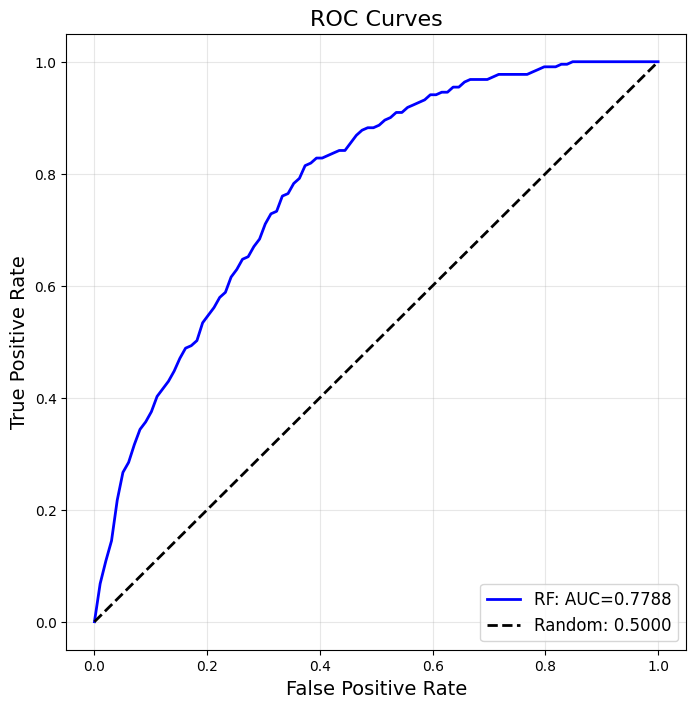

In [61]:
# Plot ROC curves
suffix = '_recall' if HIGH_RECALL else ''
plot_roc_curve(all_results, savepath=f'{TASK}_cv_mimic{suffix}_roc.png')

Baseline (positive ratio): 0.2941


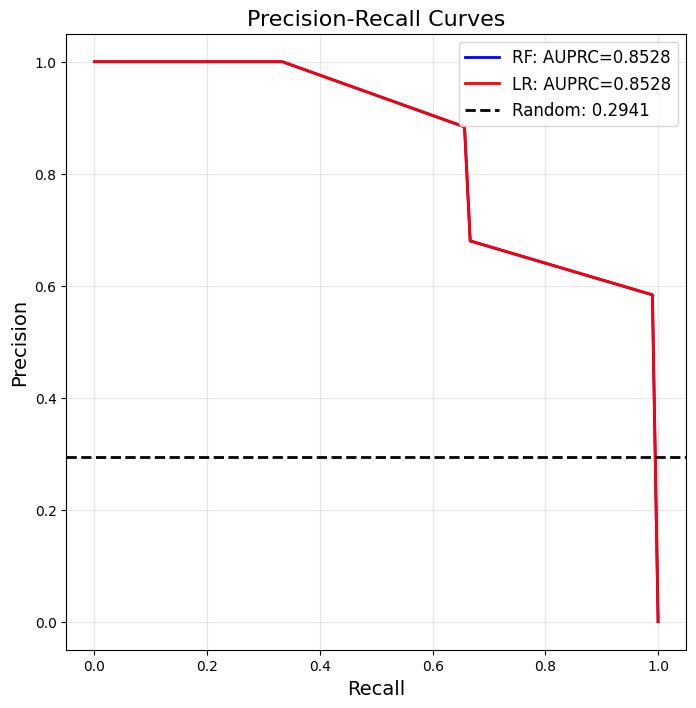

In [55]:
# Plot PR curves
baseline_ratio = sum(y) / len(y)
print(f"Baseline (positive ratio): {baseline_ratio:.4f}")
plot_pr_curve(all_results, baseline_ratio, savepath=f'{TASK}_cv_mimic{suffix}_pr.png')

## 16. Save Results

In [63]:
import json

# Save results to JSON
for model_name, result in all_results.items():
    suffix = '_recall' if HIGH_RECALL else ''
    filename = f'{MIN_TIME}min_{SKIP_TIME}skip_model_{model_name}_mimic{suffix}_CI.json'
    
    # Extract scalar metrics
    metrics_to_save = {
        'mean_auc': float(result['mean_auc']),
        'std_auc': float(result['std_auc']),
        'l_CI': float(result['l_CI']),
        'h_CI': float(result['h_CI']),
        'mean_auc_prc': float(result['mean_auc_prc']),
        'auprc_l_CI': float(result['auprc_l_CI']),
        'auprc_h_CI': float(result['auprc_h_CI']),
        'ppv': float(result['ppv']),
        'p_l_CI': float(result['p_l_CI']),
        'p_h_CI': float(result['p_h_CI']),
        'npv': float(result['npv']),
        'mcc': float(result['mcc']),
        'spec@90': float(result['spec@90']),
        'recall': float(result['rec_single']),
        'r_l_CI': float(result['r_l_CI']),
        'r_h_CI': float(result['r_h_CI']),
        'n_total': int(len(y)),
        'n_positive': int(sum(y)),
        'n_negative': int(len(y) - sum(y))
    }
    
    with open(filename, 'w') as f:
        json.dump(metrics_to_save, f, indent=2)
    
    print(f"Saved: {filename}")

Saved: 12min_12skip_model_LR_mimic_CI.json
Saved: 12min_12skip_model_RF_mimic_CI.json


## 17. Results Summary Table

In [64]:
# Create summary table
summary_data = []
for model_name, result in all_results.items():
    summary_data.append({
        'Model': model_name,
        'AUC': f"{result['mean_auc']:.4f} ({result['l_CI']:.4f}-{result['h_CI']:.4f})",
        'AUPRC': f"{result['mean_auc_prc']:.4f} ({result['auprc_l_CI']:.4f}-{result['auprc_h_CI']:.4f})",
        'PPV': f"{result['ppv']:.4f}",
        'NPV': f"{result['npv']:.4f}",
        'MCC': f"{result['mcc']:.4f}",
        'Spec@90': f"{result['spec@90']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print(f"\n=== Results Summary (min_time={MIN_TIME}h, skip_time={SKIP_TIME}h) ===")
print(summary_df.to_string(index=False))


=== Results Summary (min_time=12h, skip_time=12h) ===
Model                    AUC                  AUPRC    PPV    NPV    MCC Spec@90
   LR 0.7992 (0.7696-0.8284) 0.4218 (0.3356-0.5020) 0.3352 0.9403 0.3576  0.4015
   RF 0.8156 (0.7930-0.8384) 0.4814 (0.4070-0.5577) 0.4396 0.9263 0.3949  0.4516
